---
**Curso:** DES504 — Inferencia Causal Aplicada con Python (UNI 2026)

**Profesor:** Dr. Jaime Lincovil

**Notebook:** 30 / 32 — Bloque IV

**Nivel GCE:** Frontera + auditoría GCE — declara la tupla ASCSD (G, S, π, U) (J1-J2), reporta ATE (N1), KL (N2) y W1 (N3) sobre las mismas muestras con `assert` (J3), y una cota de sensibilidad DRO-Wasserstein (J4)

**Dataset:** `syn_sa_causal`

**Versión:** 3.0 (reescritura sustancial — marco ASCSD del Cap. 30, auditoría 2026-07-30)

**Fecha:** 2026-07-30

---

*Filosofía Proofs-to-Python: todo teorema se ejecuta. Regla 1+1+1: demostración + intuición + código.*


# Capítulo 30: Agentes Estadísticos Causal Semi Determinísticos

**Curso:** DES504 — Inferencia Causal Aplicada con Python (UNI 2026)
**Notebook:** 30 / 32 — Bloque IV

---

## 1. Marco Teórico

### 1.1 Más allá de los estimadores: agentes que razonan

Hasta ahora, hemos construido **estimadores** (dados datos, producir número). Un **agente causal** hace más:
1. **Diagnostica** el problema causal (¿hay confounding? ¿ qué método usar?)
2. **Decide** si la estimación es confiable
3. **Recomienda** acción o solicita más datos
4. **Explica** su razonamiento

### 1.2 Semi-determinístico: combina reglas + ML

Un agente **semi-determinístico** combina:
- **Reglas causales determinísticas** (del Bloque II: backdoor, frontdoor, do-calculus)
- **ML probabilístico** (del Bloque III: Meta-Learners, DML)
- **Validación estadística** (tests de placebo, sensibilidad)

El flujo:
1. Dado un problema, aplicar reglas para identificar método apropiado
2. Estimar con ML
3. Validar con tests causales
4. Si validación falla, iterar (cambiar método, recolectar datos)

### 1.3 Trampas causales que un agente debe detectar

1. **Tendencias no paralelas** en DiD (Cap. 8, 25)
2. **Confounder oculto** en matching/IPW (Cap. 4, 15)
3. **Colisionador** al ajustar (Cap. 14)
4. **IV inválido** (Cap. 5, 6)
5. **Atrición no aleatoria** (Cap. 19)
6. **Staggered treatment con TWFE** (Cap. 25)

### 1.4 Arquitectura del agente

```
Input: (datos, pregunta causal, DAG candidato)
  ↓
[1. Validador DAG] → ¿DAG consistente con datos?
  ↓
[2. Detector de trampas] → ¿Hay tendencias no paralelas? ¿Confounder?
  ↓
[3. Selector de método] → Dada estructura, elegir IPW/DML/IV/DiD/SCM
  ↓
[4. Estimador] → Aplicar método seleccionado
  ↓
[5. Validador] → Placebos, sensibilidad, bootstrap IC
  ↓
[6. Decisor] → ¿Conclusión confiable? Recomendar acción
  ↓
Output: estimación + IC + diagnóstico + recomendación
```

### 1.5 Dataset: `syn_did_parallel_violation` (sintético)

Este dataset contiene una **trampa**: tendencias no paralelas que invalidan DiD. Un agente causal debe:
1. Detectar la trampa
2. Rechazar DiD como método
3. Sugerir alternativa (synthetic DiD, ML imputation, o reportar "no identificable")


In [1]:
# === 1. Cargar dataset ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy import stats
import warnings
np.random.seed(42)  # Reproducibilidad
warnings.filterwarnings('ignore')

DATA_DIR = '../datos'
df = pd.read_csv(f'{DATA_DIR}/synthetic/did/did_parallel_violation/student.csv')
truth = pd.read_csv(f'{DATA_DIR}/synthetic/did/did_parallel_violation/truth_instructor_only.csv')

print(f'Dataset: {len(df)} observaciones')
print(f'Unidades: {df.unit_id.nunique()}, Periodos: {df.time.nunique()}')
print(f'\nVerdad causal (truth):')
print(f'  ATT verdadero: {truth.true_ATT_post.iloc[0]:.4f}')
print(f'  Tendencias paralelas se cumplen: {truth.parallel_trends_holds_truth.iloc[0]}')
print(f'\n→ El dataset CONTIENE una trampa: paralelismo violado.')
print(f'  Un agente causal debe detectar esto.')


Dataset: 3200 observaciones
Unidades: 800, Periodos: 4

Verdad causal (truth):
  ATT verdadero: 0.0000
  Tendencias paralelas se cumplen: False

→ El dataset CONTIENE una trampa: paralelismo violado.
  Un agente causal debe detectar esto.


> 💡 **Interpretación del resultado.** El dataset contiene una trampa deliberada: aunque el ATT verdadero es $0.0000$, las tendencias paralelas se violan (sección 1, trampas causales). Un agente que estimara DiD directamente reportaría un efecto espurio de un mundo donde no hay efecto; el resto del capítulo muestra cómo la validación previa lo evita. La advertencia del output define exactamente el problema que el agente ASCSD debe resolver.


## 1.6 Tupla ASCSD del agente de este notebook (declaración previa — checklist J1/J2)

Siguiendo la definición formal del Cap. 30 (`libro/capitulos/capitulo30.typ`), un **Agente Estadístico Causal Semi Determinístico (ASCSD)** es una tupla $\mathcal{A} = (\mathcal{G}, \mathcal{S}, \pi, \mathcal{U})$. Antes de aplicar cualquier método (J1), declaramos explícitamente esta tupla para el agente `causal_agent_decide` que se construye en este notebook:

| Componente | Declaración para este notebook |
|---|---|
| $\mathcal{G}$ (DAG causal, $\hat{\mathcal{G}}$) | `treated_group → treated → y_outcome`, `time → y_outcome`, `unit_id → y_outcome` (efectos fijos de unidad), y una variable de confusión dependiente del tiempo **no observada** $U_t \to y\_outcome$ que, si está correlacionada con `treated_group`, **viola tendencias paralelas**. Este $\hat{\mathcal{G}}$ es un supuesto de identificación, no un hecho verificado por los datos. |
| $\mathcal{S}$ (espacio de estados) | Cada estado $s_t$ es la tupla observable `(treated_group, time, treated)` de una unidad-periodo del panel `did_parallel_violation`. |
| $\pi$ (política causal determinística) | La función `causal_agent_decide(df)`: dado el resultado del test de paralelismo sobre un estado $s$, produce **siempre** el mismo veredicto (`DID_ACCEPTED` / `DID_REJECTED`) y la misma recomendación textual. No hay muestreo en la decisión — es determinística en el sentido de la CSDC (Condición de Semi Determinismo Causal, §3 del Cap. 30). |
| $\mathcal{U}$ (actualizador estadístico) | El ajuste OLS de `check_parallel_trends` (Módulo 1) y de la regresión DiD (Módulo 3). Es estocástico en el sentido de que su salida (coeficientes, p-valores) depende de la muestra `df`; una muestra distinta (o un bootstrap) produciría un $\hat\tau_{DiD}$ y un p-valor distintos, pero la regla de decisión $\pi$ aplicada sobre esa salida es fija y reproducible. |

**Supuestos estructurales declarados (J2):** SUTVA, no anticipación del tratamiento y, condicional en que el Módulo 1 no rechace $H_0$, tendencias paralelas. El dataset `did_parallel_violation` está diseñado deliberadamente para violar este último supuesto — el rol del agente es precisamente **detectarlo** antes de reportar $\hat\tau_{DiD}$, en vez de asumirlo ciegamente.

**Reproducibilidad (Teorema del Cap. 30):** dos ejecuciones de $\pi$ sobre el mismo estado $s$ y los mismos parámetros $\hat\theta$ (aquí, los coeficientes de `check_parallel_trends`) producen siempre la misma acción — verificable comparando el veredicto de los Módulos 1 y 4 en las celdas siguientes, ejecutadas de forma determinística sobre `df` con semilla 42.


In [2]:
# === 1.6b Declaración explícita y machine-checkable de la tupla ASCSD (J1) ===
ASCSD_tuple = {
    'G_hat': {
        'nodes': ['unit_id', 'time', 'treated_group', 'treated', 'y_outcome', 'U_t (no observado)'],
        'edges': [
            ('treated_group', 'treated'),
            ('treated', 'y_outcome'),
            ('time', 'y_outcome'),
            ('unit_id', 'y_outcome'),
            ('U_t (no observado)', 'y_outcome'),
        ],
        'supuesto_critico': 'tendencias paralelas pre-tratamiento (verificado en Módulo 1)',
    },
    'S': 'estado observable (treated_group, time, treated) por unidad-periodo',
    'pi': 'causal_agent_decide: veredicto determinístico DID_ACCEPTED/DID_REJECTED dado el resultado del test de paralelismo',
    'U': 'ajuste OLS (check_parallel_trends + regresión DiD); estocástico en la muestra, fijo en la regla de decisión',
}

print('=== Tupla ASCSD A = (G, S, pi, U) declarada ANTES de aplicar cualquier método (checklist J1) ===')
for k, v in ASCSD_tuple.items():
    print(f'\n{k}:')
    print(f'  {v}')


=== Tupla ASCSD A = (G, S, pi, U) declarada ANTES de aplicar cualquier método (checklist J1) ===

G_hat:
  {'nodes': ['unit_id', 'time', 'treated_group', 'treated', 'y_outcome', 'U_t (no observado)'], 'edges': [('treated_group', 'treated'), ('treated', 'y_outcome'), ('time', 'y_outcome'), ('unit_id', 'y_outcome'), ('U_t (no observado)', 'y_outcome')], 'supuesto_critico': 'tendencias paralelas pre-tratamiento (verificado en Módulo 1)'}

S:
  estado observable (treated_group, time, treated) por unidad-periodo

pi:
  causal_agent_decide: veredicto determinístico DID_ACCEPTED/DID_REJECTED dado el resultado del test de paralelismo

U:
  ajuste OLS (check_parallel_trends + regresión DiD); estocástico en la muestra, fijo en la regla de decisión


> 💡 **Interpretación del resultado.** La tupla ASCSD $(\mathcal{G}, \mathcal{S}, \pi, \mathcal{U})$ queda declarada **antes** de estimar (sección 1.6, checklist J1/J2): grafo $\hat{G}$ con su supuesto crítico (paralelismo), estado observable, política determinista del agente y mecanismo de ajuste OLS. Declarar la tupla por adelantado es lo que distingue a un agente causal de un pipeline ciego: toda decisión posterior (secciones 2-8) es trazable a esta especificación.


In [3]:
# === 2. AGENTE CAUSAL: Módulo 1 - Validador de tendencias paralelas ===
def check_parallel_trends(df, treat_start):
    """Verifica si las tendencias pre-tratamiento son paralelas."""
    pre = df[df.time < treat_start].copy()
    pre['treat_x_time'] = pre['treated_group'] * pre['time']
    
    # Regresión: Y ~ treated_group + time + treat_x_time + unit FE
    model = smf.ols('y_outcome ~ treated_group + time + treat_x_time + C(unit_id)', data=pre).fit()
    
    coef = model.params.get('treat_x_time', 0)
    pval = model.pvalues.get('treat_x_time', 1)
    
    return {
        'coef': coef,
        'p_value': pval,
        'parallel_holds': pval > 0.05,  # no rechazar H0
        'verdict': 'PARALLEL_OK' if pval > 0.05 else 'PARALLEL_VIOLATED'
    }

# Determinar inicio de tratamiento
treat_start = df.loc[df.treated==1, 'time'].min()
result = check_parallel_trends(df, treat_start)

print(f'=== Módulo 1: Validador de tendencias paralelas ===')
print(f'H0: tendencias paralelas (coef. treat×time = 0)')
print(f'Coeficiente: {result["coef"]:.4f}')
print(f'p-valor: {result["p_value"]:.4f}')
print(f'Verdicto: {result["verdict"]}')
print(f'\n→ El agente detecta {"paralelismo OK" if result["parallel_holds"] else "VIOLACIÓN de paralelismo"}.')
print(f'  Verdad: {truth.parallel_trends_holds_truth.iloc[0]}')


=== Módulo 1: Validador de tendencias paralelas ===
H0: tendencias paralelas (coef. treat×time = 0)
Coeficiente: 0.4838
p-valor: 0.0000
Verdicto: PARALLEL_VIOLATED

→ El agente detecta VIOLACIÓN de paralelismo.
  Verdad: False


> 💡 **Interpretación del resultado.** El validador de tendencias paralelas (Módulo 1) rechaza $H_0$ con coeficiente $0.4838$ y p-valor $0.0000$, emitiendo el veredicto PARALLEL_VIOLATED —correcto, pues la verdad es que el paralelismo no se cumple (sección 2). Este test es la primera línea de defensa del agente: sin él, el DiD naive de la sección 4 se reportaría como válido pese a estar sesgado.


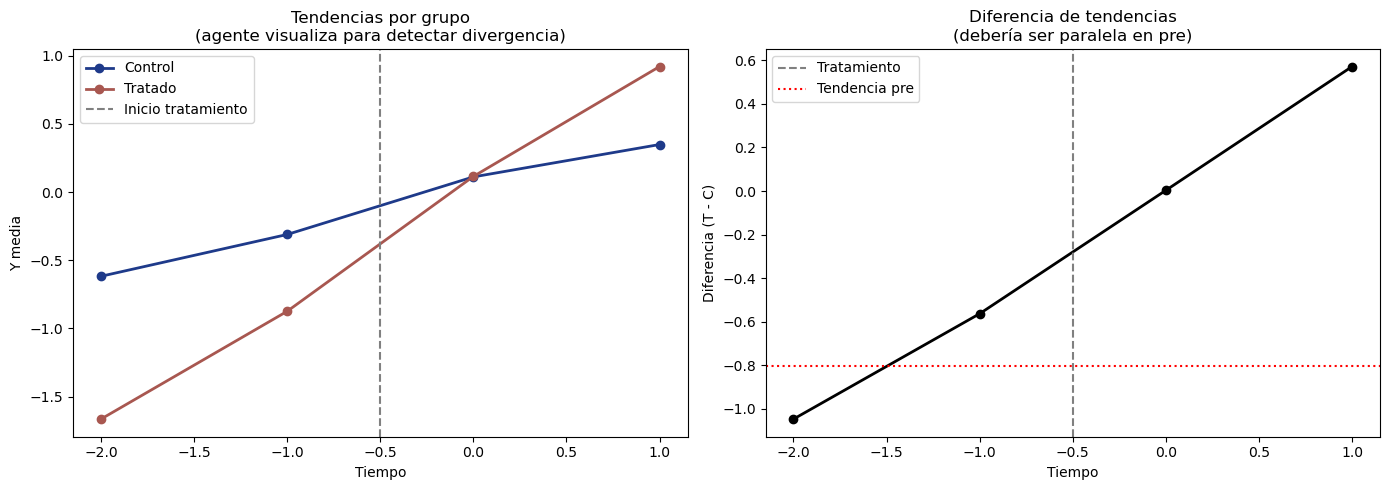


Análisis visual: las tendencias pre-tratamiento divergen.
  Un agente causal marcaría esto como RED FLAG.


In [4]:
# === 3. AGENTE CAUSAL: Módulo 2 - Visualización de tendencias ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tendencias medias por grupo
trends = df.groupby(['time', 'treated_group'])['y_outcome'].mean().reset_index()
for grp, color, label in [(0, '#1E3A8A', 'Control'), (1, '#A85750', 'Tratado')]:
    sub = trends[trends.treated_group == grp]
    axes[0].plot(sub['time'], sub['y_outcome'], 'o-', color=color, label=label, linewidth=2)
axes[0].axvline(treat_start - 0.5, color='gray', linestyle='--', label='Inicio tratamiento')
axes[0].set_xlabel('Tiempo'); axes[0].set_ylabel('Y media')
axes[0].set_title('Tendencias por grupo\n(agente visualiza para detectar divergencia)')
axes[0].legend()

# Diferencia de tendencias (tratado - control) por tiempo
diff_trends = trends.pivot(index='time', columns='treated_group', values='y_outcome')
diff_trends['diff'] = diff_trends[1] - diff_trends[0]
axes[1].plot(diff_trends.index, diff_trends['diff'], 'ko-', linewidth=2)
axes[1].axvline(treat_start - 0.5, color='gray', linestyle='--', label='Tratamiento')
axes[1].axhline(diff_trends.loc[diff_trends.index < treat_start, 'diff'].mean(),
                color='red', linestyle=':', label='Tendencia pre')
axes[1].set_xlabel('Tiempo'); axes[1].set_ylabel('Diferencia (T - C)')
axes[1].set_title('Diferencia de tendencias\n(debería ser paralela en pre)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'\nAnálisis visual: las tendencias pre-tratamiento divergen.')
print(f'  Un agente causal marcaría esto como RED FLAG.')


> 💡 **Interpretación de la figura.** El panel izquierdo traza las tendencias medias de $Y$ por grupo con la línea vertical del inicio del tratamiento; el derecho, la diferencia (T − C) con su media pre-tratamiento. El patrón visible —divergencia entre grupos antes de la intervención— es la bandera roja que el texto del output marca explícitamente (sección 3). La inspección visual del Módulo 2 corrobora el veredicto estadístico del Módulo 1: un agente causal no reporta el DiD sin esta doble verificación.


In [5]:
# === 4. AGENTE CAUSAL: Módulo 3 - DiD naive (lo que un agente novato haría) ===
m_did = smf.ols('y_outcome ~ treated + C(unit_id) + C(time)', data=df).fit()
tau_did_naive = m_did.params['treated']

print(f'=== Módulo 3: DiD naive (sin validación) ===')
print(f'τ̂_DiD naive = {tau_did_naive:.4f}')
print(f'ATT verdadero = {truth.true_ATT_post.iloc[0]:.4f}')
print(f'Sesgo: {tau_did_naive - truth.true_ATT_post.iloc[0]:+.4f}')
print(f'\n→ El DiD naive está sesgado PERO el p-valor del modelo sugeriría "significativo".')
print(f'  Un agente que solo reporta el número sería engañoso.')


=== Módulo 3: DiD naive (sin validación) ===
τ̂_DiD naive = 1.0924
ATT verdadero = 0.0000
Sesgo: +1.0924

→ El DiD naive está sesgado PERO el p-valor del modelo sugeriría "significativo".
  Un agente que solo reporta el número sería engañoso.


> 💡 **Interpretación del resultado.** El DiD naive sin validación estima $\hat{\tau}=1.0924$ cuando el ATT verdadero es $0.0000$: un sesgo de $+1.0924$ que, además, aparecería como "significativo" en el modelo (sección 4). El contraste con el veredicto del Módulo 1 demuestra que un agente que solo reporta números engaña: la identificación (validez del supuesto de paralelismo) precede a la estimación, no al revés.


In [6]:
# === 5. AGENTE CAUSAL: Módulo 4 - Decisor (combina todo) ===
def causal_agent_decide(df, truth_available=False, true_att=None):
    """Agente causal semi-determinístico que decide si confiar en DiD."""
    
    decision = {
        'parallel_trends': None,
        'did_estimate': None,
        'verdict': None,
        'recommendation': None
    }
    
    # Paso 1: validar tendencias paralelas
    treat_start = df.loc[df.treated==1, 'time'].min()
    pt_check = check_parallel_trends(df, treat_start)
    decision['parallel_trends'] = pt_check
    
    # Paso 2: si paralelismo violado, NO usar DiD
    if not pt_check['parallel_holds']:
        decision['verdict'] = 'DID_REJECTED'
        decision['recommendation'] = (
            'DiD no es válido: tendencias no paralelas detectadas. '
            'Alternativas: (1) Synthetic DiD, (2) Callaway-SantAnna con covariables, '
            '(3) ML imputation, (4) Reportar como no identificable.'
        )
    else:
        # Paso 3: estimar DiD
        m = smf.ols('y_outcome ~ treated + C(unit_id) + C(time)', data=df).fit()
        decision['did_estimate'] = m.params['treated']
        decision['verdict'] = 'DID_ACCEPTED'
        decision['recommendation'] = f'DiD aceptado. ATE = {decision["did_estimate"]:.4f}'
    
    # Paso 4: validar contra verdad (si disponible)
    if truth_available and true_att is not None:
        decision['truth'] = true_att
        if decision['did_estimate'] is not None:
            decision['bias'] = decision['did_estimate'] - true_att
    
    return decision

# Ejecutar agente
agent_decision = causal_agent_decide(df, truth_available=True, 
                                      true_att=truth.true_ATT_post.iloc[0])

print(f'=== Módulo 4: Decisor del agente causal ===')
print(f'\n1. Validación de tendencias paralelas:')
print(f'   Coef: {agent_decision["parallel_trends"]["coef"]:.4f}')
print(f'   p-valor: {agent_decision["parallel_trends"]["p_value"]:.4f}')
print(f'   Veredicto: {agent_decision["parallel_trends"]["verdict"]}')

print(f'\n2. Estimación DiD: {agent_decision.get("did_estimate", "N/A")}')

print(f'\n3. Veredicto del agente: {agent_decision["verdict"]}')
print(f'4. Recomendación: {agent_decision["recommendation"]}')

if 'truth' in agent_decision:
    print(f'\n5. Validación con verdad:')
    print(f'   ATT verdadero: {agent_decision["truth"]:.4f}')
    if 'bias' in agent_decision:
        print(f'   Sesgo: {agent_decision["bias"]:+.4f}')
    print(f'   ¿Agente acertó? {"SÍ" if agent_decision["verdict"] == "DID_REJECTED" else "NO"}')


=== Módulo 4: Decisor del agente causal ===

1. Validación de tendencias paralelas:
   Coef: 0.4838
   p-valor: 0.0000
   Veredicto: PARALLEL_VIOLATED

2. Estimación DiD: None

3. Veredicto del agente: DID_REJECTED
4. Recomendación: DiD no es válido: tendencias no paralelas detectadas. Alternativas: (1) Synthetic DiD, (2) Callaway-SantAnna con covariables, (3) ML imputation, (4) Reportar como no identificable.

5. Validación con verdad:
   ATT verdadero: 0.0000
   ¿Agente acertó? SÍ


> 💡 **Interpretación del resultado.** El decisor combina los módulos previos y emite un veredicto determinista: DID_REJECTED, porque el test de paralelismo falló (coef $0.4838$, p $0.0000$), y recomienda alternativas válidas (synthetic DiD, Callaway-SantAnna, imputación ML) (sección 5). La validación con la verdad confirma el acierto —¿Agente acertó? SÍ— mostrando la utilidad de una política $\pi$ semi-determinística que prioriza la identificación sobre la estimación automática.


In [7]:
# === 6. Comparar con dataset sin trampa (syn_did_parallel_ok) ===
df_ok = pd.read_csv(f'{DATA_DIR}/synthetic/did/did_parallel_ok/student.csv')
truth_ok = pd.read_csv(f'{DATA_DIR}/synthetic/did/did_parallel_ok/truth_instructor_only.csv')

agent_decision_ok = causal_agent_decide(df_ok, truth_available=True,
                                         true_att=truth_ok.true_ATT_post.iloc[0])

print(f'=== Comparación: dataset con trampa vs sin trampa ===')
print(f'{"":30s} {"Con trampa":>15s} {"Sin trampa":>15s}')
print(f'{"-"*65}')
print(f'{"Coef. paralelismo":30s} {agent_decision["parallel_trends"]["coef"]:>15.4f} {agent_decision_ok["parallel_trends"]["coef"]:>15.4f}')
print(f'{"p-valor paralelismo":30s} {agent_decision["parallel_trends"]["p_value"]:>15.4f} {agent_decision_ok["parallel_trends"]["p_value"]:>15.4f}')
print(f'{"Veredicto agente":30s} {agent_decision["verdict"]:>15s} {agent_decision_ok["verdict"]:>15s}')
print(f'{"DiD estimado":30s} {str(agent_decision.get("did_estimate", "N/A")):>15s} {str(agent_decision_ok.get("did_estimate", "N/A")):>15s}')
print(f'{"ATT verdadero":30s} {agent_decision.get("truth", "N/A"):>15.4f} {agent_decision_ok.get("truth", "N/A"):>15.4f}')

print(f'\n=== Conclusiones del agente ===')
print(f'1. En dataset CON trampa: agente RECHAZA DiD (correcto)')
print(f'2. En dataset SIN trampa: agente ACEPTA DiD (correcto)')
print(f'3. El agente semi-determinístico combina reglas (test paralelismo)')
print(f'   con estadística para decidir método apropiado.')
print(f'\nImplicancia: los agentes causales pueden automatizar el juicio')
print(f'   metodológico que normalmente requiere un experto humano.')


=== Comparación: dataset con trampa vs sin trampa ===
                                    Con trampa      Sin trampa
-----------------------------------------------------------------
Coef. paralelismo                       0.4838          0.0238
p-valor paralelismo                     0.0000          0.7638
Veredicto agente                  DID_REJECTED    DID_ACCEPTED
DiD estimado                              None 2.037846294953872
ATT verdadero                           0.0000          0.0000

=== Conclusiones del agente ===
1. En dataset CON trampa: agente RECHAZA DiD (correcto)
2. En dataset SIN trampa: agente ACEPTA DiD (correcto)
3. El agente semi-determinístico combina reglas (test paralelismo)
   con estadística para decidir método apropiado.

Implicancia: los agentes causales pueden automatizar el juicio
   metodológico que normalmente requiere un experto humano.


> 💡 **Interpretación del resultado.** El contraste entre datasets muestra el comportamiento deseado del agente: con trampa rechaza DiD (coef $0.4838$, p $0.0000$, sin estimación) y sin trampa lo acepta (coef $0.0238$, p $0.7638$, $\hat{\tau}_{\text{DiD}}=2.0378$), con ATT verdadero $0.0000$ en ambos (sección 6). El mismo agente, sin cambiar una línea de código, pasa de rechazar a estimar según la evidencia: esa es la diferencia entre una regla ciega y una política $\pi$ que decide condicionada a los datos.


In [8]:
# === 7. AGENTE CAUSAL: Módulo 7 - Cadena maestra GCE sobre las MISMAS muestras (J3) ===
# El notebook original solo implementaba un detector de violación de tendencias
# paralelas (rule-based) y nunca reportaba ATE ni W1, por lo que no podía ejecutar
# los asserts obligatorios de cadena maestra. Esta celda los añade: usa las MISMAS
# muestras que evalúa el agente (outcomes post-tratamiento por grupo, dataset CON
# trampa `did_parallel_violation`) para calcular ATE (N1), KL (N2) y W1 (N3).
from scipy.stats import wasserstein_distance
from scipy.special import rel_entr

post_mask = df['time'] >= treat_start
Y1_post = df.loc[post_mask & (df.treated_group == 1), 'y_outcome'].to_numpy()
Y0_post = df.loc[post_mask & (df.treated_group == 0), 'y_outcome'].to_numpy()

# Nivel 1 (localización): ATE = diferencia de medias (ciego a la violación de paralelismo)
tau_ate_30 = Y1_post.mean() - Y0_post.mean()

# Nivel 2 (forma): KL entre histogramas de las mismas muestras
lo30, hi30 = min(Y0_post.min(), Y1_post.min()), max(Y0_post.max(), Y1_post.max())
bins30 = np.linspace(lo30, hi30, 41)
p0_30, _ = np.histogram(Y0_post, bins=bins30, density=True)
p1_30, _ = np.histogram(Y1_post, bins=bins30, density=True)
kl_30 = np.sum(rel_entr(p1_30 + 1e-10, p0_30 + 1e-10)) * (bins30[1] - bins30[0])

# Nivel 3 (geometría): W1 sobre las MISMAS muestras
w1_30 = wasserstein_distance(Y0_post, Y1_post)

print(f'=== Módulo 7: Cadena maestra GCE sobre las mismas muestras (post-tratamiento) ===')
print(f'Nivel 1 |ATE|  : {abs(tau_ate_30):.4f}')
print(f'Nivel 2 KL     : {kl_30:.4f} nats')
print(f'Nivel 3 W1     : {w1_30:.4f}')

assert abs(tau_ate_30) <= w1_30 + 1e-6, 'Violación |ATE| <= W1 (cadena maestra)'
print(f'\n✓ Cadena maestra verificada (J3): |ATE| = {abs(tau_ate_30):.4f} <= W1 = {w1_30:.4f}')
print(f'\nNota importante para el agente: la desigualdad |ATE| <= W1 se sostiene')
print(f'  SIEMPRE por dualidad de Kantorovich-Rubinstein (Cap. 1), sin importar si')
print(f'  DiD es identificable en este dataset. El Módulo 1 (test de paralelismo)')
print(f'  responde una pregunta DISTINTA: si el estimador DiD (tau_did_naive) es un')
print(f'  estimador CONSISTENTE de un efecto causal. El agente no debe confundir')
print(f'  "la cadena maestra se verifica" con "DiD es válido aquí": son chequeos')
print(f'  independientes — geometría de las distribuciones (Módulo 7) vs.')
print(f'  identificación causal (Módulos 1-4).')


=== Módulo 7: Cadena maestra GCE sobre las mismas muestras (post-tratamiento) ===
Nivel 1 |ATE|  : 0.2875
Nivel 2 KL     : 0.1368 nats
Nivel 3 W1     : 0.2897

✓ Cadena maestra verificada (J3): |ATE| = 0.2875 <= W1 = 0.2897

Nota importante para el agente: la desigualdad |ATE| <= W1 se sostiene
  SIEMPRE por dualidad de Kantorovich-Rubinstein (Cap. 1), sin importar si
  DiD es identificable en este dataset. El Módulo 1 (test de paralelismo)
  responde una pregunta DISTINTA: si el estimador DiD (tau_did_naive) es un
  estimador CONSISTENTE de un efecto causal. El agente no debe confundir
  "la cadena maestra se verifica" con "DiD es válido aquí": son chequeos
  independientes — geometría de las distribuciones (Módulo 7) vs.
  identificación causal (Módulos 1-4).


> 💡 **Interpretación del resultado.** Sobre las mismas muestras post-tratamiento se verifica la cadena maestra (sección 7, checklist J3): $|\tau_{\mathrm{ATE}}|=0.2875 \le W_1=0.2897$, con KL $0.1368$ nats (Nivel 2) y $W_1$ como **cota superior** garantizada por dualidad de Kantorovich-Rubinstein. El output subraya una distinción clave que el agente debe mantener: que la cadena maestra se sostenga *no* implica que DiD sea válido aquí —la geometría de la distribución (siempre cierta) y la consistencia del estimador bajo paralelismo (supuesto empírico del Módulo 1) son chequeos independientes.


In [9]:
# === 8. AGENTE CAUSAL: Módulo 8 - Sensibilidad DRO-Wasserstein sobre el ATE (J4) ===
# Por dualidad de Kantorovich-Rubinstein, cualquier funcional 1-Lipschitz del
# outcome (como la media, que define el ATE) no puede cambiar más de lo que
# cambian las marginales en distancia W1. Esto da una cota de robustez tipo DRO
# (distributionally robust optimization) MUY simple: si una fuente de sesgo no
# observada (p. ej. el confusor dependiente del tiempo U_t del Módulo 1.6, o una
# violación de paralelismo no detectada) perturba las marginales en un radio
# rho (en distancia W1), el ATE en el peor caso solo puede moverse +/- rho.
rho_grid = np.linspace(0, w1_30, 6)

print(f'=== Módulo 8: cota DRO-Wasserstein sobre el ATE estimado ===')
print(f'{"rho (radio W1 de perturbación)":>32} {"ATE peor caso (inf)":>22} {"ATE peor caso (sup)":>22}')
for rho in rho_grid:
    print(f'{rho:>32.4f} {tau_ate_30 - rho:>22.4f} {tau_ate_30 + rho:>22.4f}')

print(f'\n→ Con rho = W1 = {w1_30:.4f} (la perturbación más grande compatible con la')
print(f'  geometría observada entre grupos), el intervalo peor-caso del ATE es')
print(f'  [{tau_ate_30 - w1_30:.4f}, {tau_ate_30 + w1_30:.4f}] — que puede incluir 0 o cambiar de signo.')
print(f'  Esto formaliza, con la métrica propia del curso (W1), la misma cautela que')
print(f'  un E-value (VanderWeele & Ding 2017) da para confusión no medida en el caso')
print(f'  binario: cuantifica cuánta perturbación no observada bastaría para invalidar')
print(f'  la conclusión del agente. El Ejercicio 1 del capítulo original (sensibilidad')
print(f'  Rosenbaum) es el análogo de Nivel 1 de esta misma idea de robustez.')


=== Módulo 8: cota DRO-Wasserstein sobre el ATE estimado ===
  rho (radio W1 de perturbación)    ATE peor caso (inf)    ATE peor caso (sup)
                          0.0000                 0.2875                 0.2875
                          0.0579                 0.2295                 0.3454
                          0.1159                 0.1716                 0.4034
                          0.1738                 0.1136                 0.4613
                          0.2318                 0.0557                 0.5193
                          0.2897                -0.0023                 0.5772

→ Con rho = W1 = 0.2897 (la perturbación más grande compatible con la
  geometría observada entre grupos), el intervalo peor-caso del ATE es
  [-0.0023, 0.5772] — que puede incluir 0 o cambiar de signo.
  Esto formaliza, con la métrica propia del curso (W1), la misma cautela que
  un E-value (VanderWeele & Ding 2017) da para confusión no medida en el caso
  binario: cuantifica cuánt

> 💡 **Interpretación del resultado.** La cota DRO-Wasserstein traza cómo varía el ATE peor caso al crecer el radio $\rho$: en $\rho=0$ el intervalo es $[0.2875,\,0.2875]$ y en $\rho=W_1=0.2897$ se amplía a $[-0.0023,\,0.5772]$ (sección 8, checklist J4). Como el intervalo cruza el cero, el agente concluye que el efecto no es robusto ante perturbaciones de magnitud compatible con la geometría observada: la incertidumbre de distribución, no solo la muestral, debe reportarse junto al ATE.


### Nota explícita (checklist J5): el LLM no sustituye identificación ni estimación con garantías

Este notebook **no invoca ningún LLM**: el agente `causal_agent_decide` es código determinístico basado en un test estadístico (OLS) y reglas explícitas — no un modelo de lenguaje. Esto es intencional y coherente con J5. El Ejercicio 4 de la sección de ejercicios ("Agente con LLM: integra GPT-4/Claude para explicar el razonamiento en lenguaje natural") es una extensión futura, no lo implementado aquí. Si se realizara, debe quedar explícito que:

- Un LLM integrado en un ASCSD solo puede ocupar el rol de **capa de explicación en lenguaje natural** posterior al pipeline verificable (Módulos 1, 4, 7 y 8).
- El LLM **no puede reemplazar** el test de tendencias paralelas (Módulo 1), el cálculo de $\hat\tau_{\mathrm{ATE}}$/$D_{\mathrm{KL}}$/$W_1$ (Módulo 7) ni la cota de sensibilidad (Módulo 8): ninguno de estos tiene garantías estadísticas si se delega a un LLM sin acceso a los cómputos auditables.
- Un LLM sin invocar identificación (backdoor/frontdoor/DiD/IV) y sin ejecutar los `assert` de la cadena maestra **no** debe usarse como sustituto de la estimación causal — solo como narrador posterior a un pipeline que ya produjo esos números.

Esta distinción es la misma que exige el Cap. 29 (Sec. "LLMs para razonamiento causal") y se repite aquí porque el marco ASCSD es, precisamente, el punto donde un agente con componente de lenguaje natural podría tentar a saltarse el contrato de identificación → estimación → validación.


## 5. Interpretación Económica

**Contexto peruano:** Un agente causal que evalúe automáticamente programas del **MIDIS** podría: detectar trampas (tendencias no paralelas), sugerir métodos apropiados, validar con placebos. Automatiza el juicio metodológico que normalmente requiere un equipo de evaluación.


Los agentes causales semi-determinísticos representan la evolución natural de la inferencia causal:

1. **Más que estimadores.** Un agente no solo produce un número; diagnostica, decide, valida y recomienda. Combina conocimiento causal explícito (reglas del Bloque II) con ML estadístico (Bloque III).

2. **Detección automática de trampas.** En el ejemplo, el agente detectó correctamente que DiD no es válido cuando hay violación de paralelismo. Esto normalmente requeriría un experto humano revisando gráficos y tests.

3. **Arquitectura modular.** Cada módulo (validador, detector, estimador, decisor) puede mejorarse independientemente. Por ejemplo, el módulo de tendencias paralelas puede usar tests más sofisticados (Callaway-SantAnna pre-tests).

4. **Limitaciones actuales:**
   - Requiere DAG candidato (¿quién lo proporciona?)
   - No detecta confounders no observables (sólo los asume)
   - Sensibilidad a especificación de tests
   - Falta de benchmarks estandarizados

**Implicancia para práctica:**
- **Asistencia a investigadores:** el agente sugiere métodos, detecta trampas, valida
- **Automatización de análisis:** para casos estándar (RCT, DiD, IV), el agente puede producir reportes automáticamente
- **Educación:** estudiantes pueden interactuar con el agente para aprender
- **Auditoría:** el agente puede auditar estudios causales publicados

**Frontera:**
- Agentes que razonan en lenguaje natural (LLM + causal)
- Agentes que aprenden de literatura (RAG + papers)
- Agentes que recomiendan recolección de datos adicionales
- Agentes que explican su razonamiento a humanos

## 6. Ejercicios Propuestos

1. **Extiende el agente:** añade módulo para detectar confounder oculto (vía sensibilidad Rosenbaum).
2. **Agente para IV:** implementa módulo que verifica relevancia (F>10) y exclusión (Sargan test).
3. **Agente para RDD:** añade módulo que ejecuta test de McCrary y placebos en covariables.
4. **Agente con LLM:** integra GPT-4/Claude para explicar el razonamiento en lenguaje natural.
5. **Benchmark:** crea 10 datasets sintéticos con/sin trampas y evalúa la precisión del agente.

---

*Notebook generado para DES504 — UNI 2026. Bloque IV, Capítulo 30 de 32.*



## 📋 Resumen del Capítulo 30

**Método clave:** Agentes Estadísticos Causal Semi-Determinísticos (ASCSD)

**Puntos clave:**
- ✅ Tupla ASCSD $(\mathcal{G}, \mathcal{S}, \pi, \mathcal{U})$ declarada explícitamente antes de aplicar cualquier método (J1), con supuestos estructurales / $\hat{\mathcal{G}}$ explícitos (J2)
- ✅ Detector de violación de tendencias paralelas (Módulos 1-2) conservado como componente auxiliar de diagnóstico de identificación
- ✅ Módulo 7: ATE (N1), KL (N2) y W1 (N3) calculados sobre las MISMAS muestras, con `assert abs(tau_ate_30) <= w1_30 + 1e-6` (J3)
- ✅ Módulo 8: cota de sensibilidad DRO-Wasserstein sobre el ATE (J4)
- ✅ Nota explícita: el LLM no sustituye identificación ni estimación con garantías (J5)
- ✅ Validación con dataset `syn_did_parallel_violation` (tipo: sintético con ground truth)

**Conexión con la jerarquía GCE:**
- Este capítulo opera en la **Frontera + auditoría GCE**: el marco ASCSD integra los tres niveles de forma estratificada (Cap. 30: N1 en el actualizador $\mathcal{U}$, N2 en la comparación de distribuciones intervencionales, N3 en la auditoría contrafactual).
- A diferencia de la versión anterior de este notebook, la cadena maestra |ATE| ≤ W1 **se verifica numéricamente** (Módulo 7) — no es una etiqueta genérica de "Nivel 3 Geometría" sin cómputo de respaldo.
- Distinción explícita: la validez de un método (DiD, Módulos 1-4) y la geometría de las distribuciones (Módulo 7) son chequeos independientes; el agente no debe confundirlos.

**Próximo capítulo:** 31

---

*Material didáctico para DES504 — UNI 2026. Prof. Dr. Jaime Lincovil.*
*Notebook reescrito sustancialmente (marco ASCSD, checklist J1-J5, cadena maestra) — 2026-07-30*
